# Countix-AV dataset explorer

This notebook analyses the Countix-AV train, validation, and test annotations together with the locally available videos and extracted WAV tracks.


## 1. Setup

Place the notebook in the project root, next to `annotations/`, `videos/`, and `audios/`. Edit the paths below only if your layout differs.


In [1]:
from pathlib import Path
from urllib.parse import quote
import html
import json
import re
import uuid
import wave

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SPLIT_ORDER = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#2563eb", "val": "#f59e0b", "test": "#10b981"}
VIDEO_SUFFIXES = {".mp4", ".mkv", ".webm", ".mov", ".m4v", ".avi"}
AUDIO_SUFFIXES = {".wav"}


In [2]:
ANNOTATIONS_DIR = Path("annotations")
VIDEO_ROOT = Path("videos")
AUDIO_ROOT = Path("audios")

print(f"Annotations: {ANNOTATIONS_DIR.resolve()}")
print(f"Videos:      {VIDEO_ROOT.resolve()}")
print(f"Audio:       {AUDIO_ROOT.resolve()}")


Annotations: /mnt/Workspace/audiovisual-video-repetition-counting/data/CountixAV/annotations
Videos:      /mnt/Workspace/audiovisual-video-repetition-counting/data/CountixAV/videos
Audio:       /mnt/Workspace/audiovisual-video-repetition-counting/data/CountixAV/audios


## 2. Load and prepare annotations

Each row identifies a Kinetics clip and one annotated repetition window. The absolute repetition timestamps are also converted to positions relative to the local Kinetics clip.


In [3]:
REQUIRED_COLUMNS = [
    "video_name",
    "count",
    "fps",
    "repetition_segment_start_sec",
    "repetition_segment_end_sec",
]


def find_split_csv(directory, split):
    preferred = [
        directory / f"Countix_{split}.csv",
        directory / f"CountixAV_{split}.csv",
        directory / f"countixav_{split}.csv",
        directory / f"countixAV_{split}.csv",
        directory / f"{split}.csv",
    ]
    for path in preferred:
        if path.is_file():
            return path
    matches = sorted(
        path
        for path in directory.glob("*.csv")
        if split in path.stem.lower() and "local" not in path.stem.lower()
    )
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one annotation CSV for '{split}' in {directory}; found {len(matches)}."
        )
    return matches[0]


def time_token(value):
    value = float(value)
    if value.is_integer():
        return f"{int(value):06d}"
    return f"{value:.6f}".rstrip("0").rstrip(".").replace(".", "p")


def make_clip_stem(video_id, start, end):
    return f"{video_id}_{time_token(start)}_{time_token(end)}"


def extract_original_info(video_name):
    # Extract video_id, kinetics_start, and kinetics_end from video_name
    stem = str(video_name).rsplit(".", 1)[0]
    parts = stem.split("_")
    if len(parts) > 2:
        vid_id = "_".join(parts[:-2])
        try:
            k_start = float(parts[-2].replace("p", "."))
            k_end = float(parts[-1].replace("p", "."))
            return vid_id, k_start, k_end
        except ValueError:
            pass
    return stem, 0.0, 0.0


datasets = {}
annotation_paths = {}
for split in SPLIT_ORDER:
    path = find_split_csv(ANNOTATIONS_DIR, split)
    frame = pd.read_csv(path).copy()
    
    missing = set(REQUIRED_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns: {', '.join(sorted(missing))}")
        
    numeric_cols = ["count", "fps", "repetition_segment_start_sec", "repetition_segment_end_sec"]
    for column in numeric_cols:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
        
    frame["split"] = split
    frame["row_in_split"] = np.arange(len(frame))
    
    # Reconstruct original columns by parsing the filename
    parsed_info = frame["video_name"].apply(extract_original_info)
    frame["video_id"] = parsed_info.apply(lambda x: x[0])
    frame["kinetics_start"] = parsed_info.apply(lambda x: x[1])
    frame["kinetics_end"] = parsed_info.apply(lambda x: x[2])
    
    # Reconstruct absolute repetition times
    frame["repetition_start"] = frame["kinetics_start"] + frame["repetition_segment_start_sec"]
    frame["repetition_end"] = frame["kinetics_start"] + frame["repetition_segment_end_sec"]
    
    frame["source_video_id"] = frame["video_id"].astype(str)
    
    # clip_stem is the filename without extension
    frame["clip_stem"] = frame["video_name"].apply(lambda x: str(x).rsplit(".", 1)[0])
    
    datasets[split] = frame
    annotation_paths[split] = path

annotations = pd.concat(datasets.values(), ignore_index=True, sort=False)
annotations["split"] = pd.Categorical(
    annotations["split"], SPLIT_ORDER, ordered=True
)

# Recompute derivatives expected by downstream cells
annotations["kinetics_duration_sec"] = (
    annotations["kinetics_end"] - annotations["kinetics_start"]
)

# Map the new segment columns back to the expected local_sec columns
annotations["repetition_start_local_sec"] = annotations["repetition_segment_start_sec"]
annotations["repetition_end_local_sec"] = annotations["repetition_segment_end_sec"]

annotations["repetition_duration_sec"] = (
    annotations["repetition_end_local_sec"] - annotations["repetition_start_local_sec"]
)
annotations["repetition_coverage"] = (
    annotations["repetition_duration_sec"] / annotations["kinetics_duration_sec"]
)
annotations["mean_cycle_duration_sec"] = (
    annotations["repetition_duration_sec"] / annotations["count"]
)

print(
    f"Loaded {len(annotations):,} annotation rows representing "
    f"{annotations['clip_stem'].nunique():,} unique Kinetics clips."
)

Loaded 1,795 annotation rows representing 1,589 unique Kinetics clips.


## 3. Dataset overview

The summary distinguishes annotation rows, Kinetics clips, and original YouTube IDs. Multiple rows may refer to the same clip.


In [4]:
overview = (
    annotations.groupby("split", observed=True)
    .agg(
        annotation_rows=("video_id", "size"),
        unique_kinetics_clips=("clip_stem", "nunique"),
        unique_source_videos=("source_video_id", "nunique"),
        annotated_repetitions=("count", "sum"),
        median_count=("count", "median"),
        maximum_count=("count", "max"),
        median_kinetics_duration_sec=("kinetics_duration_sec", "median"),
        median_repetition_window_sec=("repetition_duration_sec", "median"),
        median_repetition_coverage=("repetition_coverage", "median"),
    )
    .reindex(SPLIT_ORDER)
)

total = pd.DataFrame(
    {
        "annotation_rows": [len(annotations)],
        "unique_kinetics_clips": [annotations["clip_stem"].nunique()],
        "unique_source_videos": [annotations["source_video_id"].nunique()],
        "annotated_repetitions": [annotations["count"].sum()],
        "median_count": [annotations["count"].median()],
        "maximum_count": [annotations["count"].max()],
        "median_kinetics_duration_sec": [annotations["kinetics_duration_sec"].median()],
        "median_repetition_window_sec": [annotations["repetition_duration_sec"].median()],
        "median_repetition_coverage": [annotations["repetition_coverage"].median()],
    },
    index=["all"],
)
overview_with_total = pd.concat([overview, total])
display(overview_with_total.round(3))


,annotation_rows,unique_kinetics_clips,unique_source_videos,annotated_repetitions,median_count,maximum_count,median_kinetics_duration_sec,median_repetition_window_sec,median_repetition_coverage
train,934,820,807,"7,848.000",5.000,52.000,10.000,6.000,0.600
val,310,274,272,"2,676.000",5.500,56.000,10.000,5.720,0.572
test,551,497,494,"4,216.000",5.000,54.000,10.000,5.620,0.562
all,1795,1589,1572,"14,740.000",5.000,56.000,10.000,5.800,0.580


### Annotation distributions

These plots show dataset size, repetition counts, and how much of each Kinetics clip is covered by the annotated repetitive action.


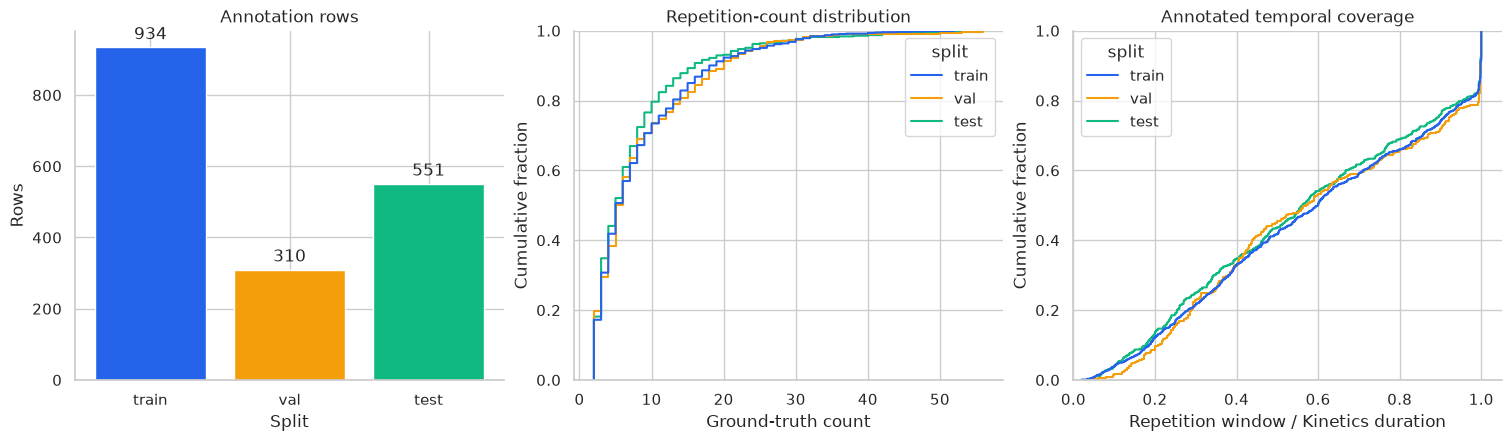

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

split_sizes = annotations["split"].value_counts(sort=False).reindex(SPLIT_ORDER)
axes[0].bar(
    split_sizes.index,
    split_sizes.values,
    color=[SPLIT_COLORS[split] for split in SPLIT_ORDER],
)
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)
axes[0].set(title="Annotation rows", xlabel="Split", ylabel="Rows")

sns.ecdfplot(
    data=annotations,
    x="count",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[1],
)
axes[1].set(
    title="Repetition-count distribution",
    xlabel="Ground-truth count",
    ylabel="Cumulative fraction",
)

sns.ecdfplot(
    data=annotations,
    x="repetition_coverage",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[2],
)
axes[2].set(
    title="Annotated temporal coverage",
    xlabel="Repetition window / Kinetics duration",
    ylabel="Cumulative fraction",
)
axes[2].set_xlim(0, max(1.05, annotations["repetition_coverage"].quantile(0.995)))

sns.despine()
plt.show()


## 4. Video and audio inventory

Files are matched by the 11-character YouTube ID and the two Kinetics timestamps. Additional filename fields are ignored. WAV metadata are read without decoding the full audio signal.


In [6]:
def media_lookup_key(filename):
    stem = Path(filename).stem
    if len(stem) < 12 or stem[11] != "_":
        return None
    fields = stem[12:].split("_")
    if len(fields) < 2:
        return None
    try:
        start = round(float(fields[0].replace("p", ".")), 6)
        end = round(float(fields[1].replace("p", ".")), 6)
    except ValueError:
        return None
    return stem[:11], start, end


def build_media_index(root, suffixes):
    index = {}
    if not root.is_dir():
        return index
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in suffixes:
            key = media_lookup_key(path.name)
            if key is not None:
                index.setdefault(key, []).append(path)
    for paths in index.values():
        paths.sort()
    return index


def row_lookup_key(row):
    return (
        str(row["video_id"]),
        round(float(row["kinetics_start"]), 6),
        round(float(row["kinetics_end"]), 6),
    )


def choose_path(paths, clip_stem):
    if not paths:
        return None
    return sorted(paths, key=lambda path: (path.stem != clip_stem, str(path)))[0]


def probe_wav(path):
    try:
        with wave.open(str(path), "rb") as handle:
            channels = handle.getnchannels()
            sample_rate = handle.getframerate()
            sample_width_bytes = handle.getsampwidth()
            sample_frames = handle.getnframes()
        duration = sample_frames / sample_rate if sample_rate else np.nan
        return {
            "audio_duration_sec": duration,
            "sample_rate_hz": sample_rate,
            "channels": channels,
            "sample_width_bits": sample_width_bytes * 8,
            "audio_probe_error": "",
        }
    except Exception as exc:
        return {
            "audio_duration_sec": np.nan,
            "sample_rate_hz": np.nan,
            "channels": np.nan,
            "sample_width_bits": np.nan,
            "audio_probe_error": f"{type(exc).__name__}: {exc}",
        }


video_index = build_media_index(VIDEO_ROOT, VIDEO_SUFFIXES)
audio_index = build_media_index(AUDIO_ROOT, AUDIO_SUFFIXES)

unique_clips = (
    annotations[
        [
            "clip_stem",
            "video_id",
            "kinetics_start",
            "kinetics_end",
            "kinetics_duration_sec",
        ]
    ]
    .drop_duplicates("clip_stem")
    .reset_index(drop=True)
)

inventory_rows = []
for _, row in unique_clips.iterrows():
    key = row_lookup_key(row)
    video_path = choose_path(video_index.get(key, []), row["clip_stem"])
    audio_path = choose_path(audio_index.get(key, []), row["clip_stem"])
    record = {
        "clip_stem": row["clip_stem"],
        "video_path": video_path,
        "audio_path": audio_path,
        "video_available": video_path is not None,
        "audio_available": audio_path is not None,
        "video_matches": len(video_index.get(key, [])),
        "audio_matches": len(audio_index.get(key, [])),
        "expected_duration_sec": row["kinetics_duration_sec"],
    }
    if audio_path is not None:
        record.update(probe_wav(audio_path))
    else:
        record.update(
            {
                "audio_duration_sec": np.nan,
                "sample_rate_hz": np.nan,
                "channels": np.nan,
                "sample_width_bits": np.nan,
                "audio_probe_error": "",
            }
        )
    inventory_rows.append(record)

media_inventory = pd.DataFrame(inventory_rows)
media_inventory["audio_duration_error_sec"] = (
    media_inventory["audio_duration_sec"]
    - media_inventory["expected_duration_sec"]
)
media_inventory["absolute_audio_duration_error_sec"] = (
    media_inventory["audio_duration_error_sec"].abs()
)

clip_split_inventory = (
    annotations[["split", "clip_stem"]]
    .drop_duplicates()
    .merge(media_inventory, on="clip_stem", how="left")
)

audio_overview = (
    clip_split_inventory.groupby("split", observed=True)
    .agg(
        expected_clips=("clip_stem", "size"),
        videos_found=("video_available", "sum"),
        audios_found=("audio_available", "sum"),
        median_audio_duration_sec=("audio_duration_sec", "median"),
        median_absolute_duration_error_sec=(
            "absolute_audio_duration_error_sec",
            "median",
        ),
    )
    .reindex(SPLIT_ORDER)
)
audio_overview["video_coverage"] = (
    audio_overview["videos_found"] / audio_overview["expected_clips"]
)
audio_overview["audio_coverage"] = (
    audio_overview["audios_found"] / audio_overview["expected_clips"]
)
display(audio_overview.round(3))

available_audio = media_inventory.loc[media_inventory["audio_available"]]
if len(available_audio):
    technical_audio_summary = pd.DataFrame(
        {
            "value": [
                len(available_audio),
                available_audio["sample_rate_hz"].nunique(dropna=True),
                available_audio["channels"].nunique(dropna=True),
                available_audio["sample_width_bits"].nunique(dropna=True),
                int(available_audio["audio_probe_error"].ne("").sum()),
            ]
        },
        index=[
            "WAV files",
            "Distinct sample rates",
            "Distinct channel counts",
            "Distinct sample widths",
            "Probe failures",
        ],
    )
    display(technical_audio_summary)
else:
    print("No matching WAV files were found. Run the audio-extraction script first.")


,expected_clips,videos_found,audios_found,median_audio_duration_sec,median_absolute_duration_error_sec,video_coverage,audio_coverage
split,,,,,,,
train,820,820,820,10.008,0.008,1.000,1.000
val,274,274,274,9.996,0.014,1.000,1.000
test,497,497,497,9.994,0.008,1.000,1.000


,value
WAV files,1589
Distinct sample rates,1
Distinct channel counts,1
Distinct sample widths,1
Probe failures,0


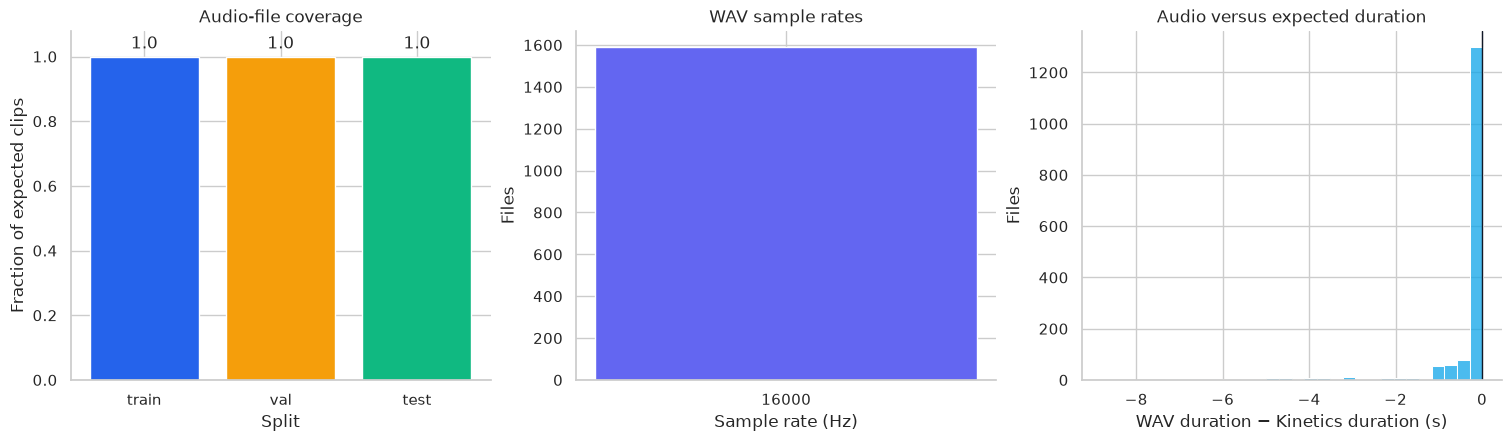

In [7]:
if len(available_audio):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

    coverage = audio_overview["audio_coverage"].fillna(0)
    axes[0].bar(
        coverage.index,
        coverage.values,
        color=[SPLIT_COLORS[split] for split in SPLIT_ORDER],
    )
    axes[0].bar_label(axes[0].containers[0], fmt="%.1f", padding=3)
    axes[0].set(
        title="Audio-file coverage",
        xlabel="Split",
        ylabel="Fraction of expected clips",
        ylim=(0, 1.08),
    )

    sample_rate_counts = available_audio["sample_rate_hz"].value_counts().sort_index()
    axes[1].bar(
        sample_rate_counts.index.astype(str),
        sample_rate_counts.values,
        color="#6366f1",
    )
    axes[1].set(
        title="WAV sample rates",
        xlabel="Sample rate (Hz)",
        ylabel="Files",
    )

    duration_errors = available_audio["audio_duration_error_sec"].dropna()
    if len(duration_errors):
        sns.histplot(duration_errors, bins=30, color="#0ea5e9", ax=axes[2])
        axes[2].axvline(0, color="#111827", linewidth=1)
    axes[2].set(
        title="Audio versus expected duration",
        xlabel="WAV duration − Kinetics duration (s)",
        ylabel="Files",
    )

    sns.despine()
    plt.show()


## 5. Annotation and media checks

These checks cover timestamp validity, duplicate annotations, cross-split overlap, missing media, WAV readability, and audiovisual duration alignment.


In [8]:
invalid_kinetics = annotations["kinetics_end"].le(annotations["kinetics_start"])
invalid_repetition = annotations["repetition_end"].le(annotations["repetition_start"])
repetition_outside_kinetics = (
    annotations["repetition_start"].lt(annotations["kinetics_start"] - 0.05)
    | annotations["repetition_end"].gt(annotations["kinetics_end"] + 0.05)
)
invalid_count = annotations["count"].le(0) | annotations["count"].isna()
clip_split_counts = annotations.groupby("clip_stem", observed=True)["split"].nunique()

checks = pd.DataFrame(
    {
        "diagnostic": [
            "Rows with missing required values",
            "Rows with invalid Kinetics intervals",
            "Rows with invalid repetition intervals",
            "Repetition windows outside Kinetics bounds",
            "Rows with non-positive counts",
            "Exact duplicate annotation rows",
            "Kinetics clips present in multiple splits",
            "Expected clips without a video",
            "Expected clips without a WAV file",
            "WAV files that could not be probed",
            "WAV duration differs by more than 0.25 s",
            "WAV files that are not mono",
            "WAV files not sampled at 16 kHz",
        ],
        "affected": [
            int(annotations[REQUIRED_COLUMNS].isna().any(axis=1).sum()),
            int(invalid_kinetics.sum()),
            int(invalid_repetition.sum()),
            int(repetition_outside_kinetics.sum()),
            int(invalid_count.sum()),
            int(annotations.duplicated(subset=REQUIRED_COLUMNS).sum()),
            int(clip_split_counts.gt(1).sum()),
            int((~media_inventory["video_available"]).sum()),
            int((~media_inventory["audio_available"]).sum()),
            int(media_inventory["audio_probe_error"].ne("").sum()),
            int(media_inventory["absolute_audio_duration_error_sec"].gt(0.25).sum()),
            int(available_audio["channels"].ne(1).sum()),
            int(available_audio["sample_rate_hz"].ne(16000).sum()),
        ],
    }
)
display(checks)

missing_videos = media_inventory.loc[
    ~media_inventory["video_available"], ["clip_stem"]
].reset_index(drop=True)
missing_audios = media_inventory.loc[
    ~media_inventory["audio_available"], ["clip_stem"]
].reset_index(drop=True)
audio_duration_mismatches = media_inventory.loc[
    media_inventory["absolute_audio_duration_error_sec"].gt(0.25),
    [
        "clip_stem",
        "expected_duration_sec",
        "audio_duration_sec",
        "audio_duration_error_sec",
        "audio_path",
    ],
].reset_index(drop=True)


,diagnostic,affected
0,Rows with missing required values,0
1,Rows with invalid Kinetics intervals,0
2,Rows with invalid repetition intervals,0
3,Repetition windows outside Kinetics bounds,0
4,Rows with non-positive counts,0
5,Exact duplicate annotation rows,0
6,Kinetics clips present in multiple splits,2
7,Expected clips without a video,0
8,Expected clips without a WAV file,0
9,WAV files that could not be probed,0


## 6. Select examples

The table selects low-, median-, and high-count annotations from each split, preferring examples for which both video and audio are available.


In [9]:
annotations_with_media = annotations.merge(
    media_inventory[
        ["clip_stem", "video_available", "audio_available", "video_path", "audio_path"]
    ],
    on="clip_stem",
    how="left",
)

example_rows = []
for split in SPLIT_ORDER:
    split_frame = annotations_with_media.loc[
        annotations_with_media["split"].eq(split)
    ].copy()
    complete = split_frame.loc[
        split_frame["video_available"] & split_frame["audio_available"]
    ]
    candidates = complete if len(complete) else split_frame
    candidates = candidates.sort_values("count")
    if not len(candidates):
        continue
    positions = {
        "low count": 0,
        "median count": len(candidates) // 2,
        "high count": len(candidates) - 1,
    }
    for label, position in positions.items():
        row = candidates.iloc[position]
        example_rows.append(
            {
                "split": split,
                "selection": label,
                "row_in_split": int(row["row_in_split"]),
                "clip_stem": row["clip_stem"],
                "count": row["count"],
                "repetition_window_sec": row["repetition_duration_sec"],
                "video": bool(row["video_available"]),
                "audio": bool(row["audio_available"]),
            }
        )

examples = pd.DataFrame(example_rows)
display(examples)


,split,selection,row_in_split,clip_stem,count,repetition_window_sec,video,audio
0,train,low count,922,393hVY7pxHw_000021_000031,2.000,3.840,True,True
1,train,median count,37,l0IbxJrvkps_000000_000010,5.000,3.910,True,True
2,train,high count,814,vcfHHoyi7BE_000052_000062,52.000,10.000,True,True
3,val,low count,2,AtEODzq0S6A_000037_000047,2.000,2.710,True,True
4,val,median count,297,X8ueUhQK7mw_000034_000044,6.000,10.000,True,True
5,val,high count,277,C0Gc0RxDx6E_000017_000027,56.000,10.000,True,True
6,test,low count,548,8NXFPGqHLdE_000055_000065,2.000,3.880,True,True
7,test,median count,546,7Uv-26v3k00_000021_000031,5.000,9.980,True,True
8,test,high count,396,1u0XZLcBcp0_000014_000024,54.000,8.890,True,True


## 7. Synchronized video, audio waveform, and annotation

The waveform is read from the extracted WAV file. Its playhead follows the video, while the highlighted region shows the annotated repetition window. Click the waveform to seek; audio playback comes from the video track.


In [14]:
def get_annotation_row(split="train", row_number=0):
    frame = annotations_with_media.loc[annotations_with_media["split"].eq(split)]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def wav_duration_seconds(path):
    with wave.open(str(path), "rb") as handle:
        sample_rate = handle.getframerate()
        frame_count = handle.getnframes()
    if sample_rate <= 0:
        raise ValueError("WAV sample rate is unavailable")
    return frame_count / sample_rate


def read_waveform_envelope(path, max_bins=900):
    with wave.open(str(path), "rb") as handle:
        channels = handle.getnchannels()
        sample_width = handle.getsampwidth()
        frame_count = handle.getnframes()
        raw = handle.readframes(frame_count)

    if sample_width == 1:
        samples = np.frombuffer(raw, dtype=np.uint8).astype(np.float32) - 128
    elif sample_width == 2:
        samples = np.frombuffer(raw, dtype="<i2").astype(np.float32)
    elif sample_width == 3:
        bytes_ = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3)
        values = (
            bytes_[:, 0].astype(np.int32)
            | (bytes_[:, 1].astype(np.int32) << 8)
            | (bytes_[:, 2].astype(np.int32) << 16)
        )
        values = np.where(values & 0x800000, values - 0x1000000, values)
        samples = values.astype(np.float32)
    elif sample_width == 4:
        samples = np.frombuffer(raw, dtype="<i4").astype(np.float32)
    else:
        raise ValueError(f"Unsupported WAV sample width: {sample_width} bytes")

    if channels > 1:
        samples = samples.reshape(-1, channels).mean(axis=1)
    if not len(samples):
        return np.array([0.0]), np.array([0.0])
    peak = float(np.max(np.abs(samples)))
    if peak > 0:
        samples = samples / peak

    bin_count = min(max_bins, len(samples))
    edges = np.linspace(0, len(samples), bin_count + 1, dtype=int)
    minima = np.empty(bin_count, dtype=float)
    maxima = np.empty(bin_count, dtype=float)
    for index in range(bin_count):
        chunk = samples[edges[index] : edges[index + 1]]
        minima[index] = chunk.min() if len(chunk) else 0.0
        maxima[index] = chunk.max() if len(chunk) else 0.0
    return minima, maxima


def waveform_polygon(minima, maxima, width=1000, height=140):
    if len(minima) == 1:
        x_values = np.array([0.0])
    else:
        x_values = np.linspace(0, width, len(minima))
    upper = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values, maxima)
    ]
    lower = [
        f"{x:.2f},{height * (0.5 - 0.43 * value):.2f}"
        for x, value in zip(x_values[::-1], minima[::-1])
    ]
    return " ".join(upper + lower)


def show_countixav_example(split="train", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = row.get("audio_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['clip_stem']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    # Use the WAV duration immediately; browser metadata will replace it with
    # the exact video duration as soon as the video is loaded.
    annotation_duration = float(row.get("kinetics_duration_sec", 0))
    duration = annotation_duration if annotation_duration > 0 else 10.0
    if isinstance(audio_path, Path) and audio_path.is_file():
        try:
            measured_audio_duration = wav_duration_seconds(audio_path)
            if np.isfinite(measured_audio_duration) and measured_audio_duration > 0:
                duration = measured_audio_duration
        except Exception:
            pass

    fps = float(row.get("fps", 30.0))
    repetition_start = max(0.0, float(row["repetition_start_local_sec"]))
    repetition_end = min(duration, float(row["repetition_end_local_sec"]))
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    video_filename = str(row.get("video_name", video_path.name))

    count_val = int(round(float(row.get("count", 0))))
    repetition_blocks_html = ""
    
    if count_val > 0 and fps > 0:
        segment_start_sec = repetition_start
        segment_end_sec = repetition_end
        total_segment_duration = segment_end_sec - segment_start_sec
        
        if total_segment_duration > 0:
            for i in range(1, count_val + 1):
                start_frame_key = f"rep_start_frame_{i}"
                end_frame_key = f"rep_end_frame_{i}"
                
                if start_frame_key in row and end_frame_key in row and not pd.isna(row[start_frame_key]):
                    f_start = float(row[start_frame_key])
                    f_end = float(row[end_frame_key])
                    
                    rep_s = segment_start_sec + (f_start / fps) - (float(row.get("segment_start_frame", 0)) / fps)
                    rep_e = segment_start_sec + (f_end / fps) - (float(row.get("segment_start_frame", 0)) / fps)
                else:
                    rep_s = segment_start_sec + (i - 1) * total_segment_duration / count_val
                    rep_e = segment_start_sec + i * total_segment_duration / count_val
                
                rep_left = max(0.0, 100 * rep_s / duration)
                rep_w = max(0.0, 100 * (rep_e - rep_s) / duration)
                
                repetition_blocks_html += f'''
                  <div class="single-repetition" data-start="{rep_s:.9f}" data-end="{rep_e:.9f}" style="left: {rep_left:.4f}%; width: {rep_w:.4f}%;" title="Rep {i}">
                    <span>{i}</span>
                  </div>
                '''

    waveform_points = ""
    waveform_note = "WAV not available"
    if isinstance(audio_path, Path) and audio_path.is_file():
        try:
            minima, maxima = read_waveform_envelope(audio_path)
            waveform_points = waveform_polygon(minima, maxima)
            waveform_note = html.escape(audio_path.name)
        except Exception as exc:
            waveform_note = html.escape(f"Waveform unavailable: {exc}")

    uid = f"countixav-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="countixav-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border: 1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000000; border-radius:8px; }}
        #{uid} .wave-wrap {{ position:relative; margin-top:12px; height:140px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} svg {{ display:block; width:100%; height:100%; }}
        #{uid} .annotation {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; background:rgba(245,158,11,.25); border-left:2px solid #f59e0b; border-right:2px solid #f59e0b; pointer-events:none; }}
        #{uid} .playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,0.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing: border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
        #{uid} .audio-note {{ color:#94a3b8; font-size:12px; margin-top:3px; }}
      </style>
      <div class="meta">
        <span><strong>Clip:</strong> {html.escape(str(row['clip_stem']))}</span>
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
      </div>
      <video controls preload="metadata" src="{video_url}"></video>
      <div class="wave-wrap" role="slider" aria-label="Audio waveform and repetition window"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <svg viewBox="0 0 1000 140" preserveAspectRatio="none" role="img" aria-label="Audio waveform">
          <line x1="0" y1="70" x2="1000" y2="70" stroke="#64748b" stroke-width="1" />
          <polygon points="{waveform_points}" fill="#38bdf8" opacity="0.8" />
        </svg>
        <div class="annotation" data-start="{repetition_start:.9f}" data-end="{repetition_end:.9f}" aria-hidden="true"></div>
        <div class="playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="audio-note">Waveform: {waveform_note}</div>
      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>
      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const waveform = root.querySelector('.wave-wrap');
          const playhead = root.querySelector('.playhead');
          const annotation = root.querySelector('.annotation');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const status = root.querySelector('.status');
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(
              annotation,
              Number(annotation.dataset.start),
              Number(annotation.dataset.end),
            );
            repetitionBlocks.forEach(block => {{
              layoutRange(block, Number(block.dataset.start), Number(block.dataset.end));
            }});
            waveform.setAttribute('aria-valuemax', duration.toFixed(3));
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            playhead.style.left = `${{100 * t / duration}}%`;
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            waveform.setAttribute('aria-valuenow', t.toFixed(3));
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = (event, track) => {{
            const bounds = track.getBoundingClientRect();
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};
          waveform.addEventListener('click', event => seekFromTrack(event, waveform));
          timeline.addEventListener('click', event => seekFromTrack(event, timeline));
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});
          layoutTracks();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

In [28]:
# Change these two values to inspect another annotation row.
EXAMPLE_SPLIT = "train"
EXAMPLE_ROW = 228

show_countixav_example(EXAMPLE_SPLIT, EXAMPLE_ROW)


`EXAMPLE_ROW` refers to the original row order within the selected split. The browser must be able to serve both the notebook and media files from the same Jupyter root.


In [29]:
# Canva export: set the toggle to True to render the selected example as an MP4.
# The export contains the video, WAV audio, waveform, repetition window, and moving cursors.
EXPORT_CANVA_MP4 = True
CANVA_EXPORT_DIR = Path("canva_exports")


def export_canva_mp4(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    output_dir=CANVA_EXPORT_DIR,
    fps=30,
):
    import shutil
    import subprocess
    import tempfile

    def probe_duration(path, ffprobe_executable):
        """Return the container duration reported by FFprobe, or NaN."""
        if ffprobe_executable is None:
            return float("nan")
        probe = subprocess.run(
            [
                ffprobe_executable,
                "-v", "error",
                "-show_entries", "format=duration",
                "-of", "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            capture_output=True,
            text=True,
        )
        if probe.returncode != 0:
            return float("nan")
        try:
            value = float(probe.stdout.strip())
        except (TypeError, ValueError):
            return float("nan")
        return value if np.isfinite(value) and value > 0 else float("nan")

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None:
        raise RuntimeError(
            "FFmpeg is required for MP4 export. Install it and restart the kernel."
        )

    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    audio_path = row.get("audio_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        raise FileNotFoundError(f"Video not found for {row['clip_stem']}")
    if not isinstance(audio_path, Path) or not audio_path.is_file():
        raise FileNotFoundError(f"WAV audio not found for {row['clip_stem']}")

    # Use the real media duration rather than the nominal 10 s Kinetics window.
    video_duration = probe_duration(video_path, ffprobe)
    audio_duration = probe_duration(audio_path, ffprobe)
    if not np.isfinite(audio_duration):
        audio_duration = wav_duration_seconds(audio_path)

    valid_media_durations = [
        value
        for value in (video_duration, audio_duration)
        if np.isfinite(value) and value > 0
    ]
    if valid_media_durations:
        # Taking the shorter stream prevents a frozen/blank tail if container
        # durations differ slightly after extraction.
        duration = min(valid_media_durations)
    else:
        duration = float(row["kinetics_duration_sec"])

    if not np.isfinite(duration) or duration <= 0:
        raise ValueError(f"Invalid clip duration: {duration}")

    repetition_start = np.clip(
        float(row["repetition_start_local_sec"]), 0.0, duration
    )
    repetition_end = np.clip(
        float(row["repetition_end_local_sec"]), repetition_start, duration
    )
    minima, maxima = read_waveform_envelope(audio_path, max_bins=1600)
    times = np.linspace(0.0, duration, len(minima))

    # Recreate the same numbered repetition blocks used by the HTML player.
    repetition_intervals = []
    count_val = int(round(float(row.get("count", 0))))
    metadata_fps = float(row.get("fps", 30.0))
    repetition_window_duration = repetition_end - repetition_start
    if count_val > 0 and metadata_fps > 0 and repetition_window_duration > 0:
        segment_start_frame = float(row.get("segment_start_frame", 0))
        for repetition_index in range(1, count_val + 1):
            start_key = f"rep_start_frame_{repetition_index}"
            end_key = f"rep_end_frame_{repetition_index}"
            if (
                start_key in row
                and end_key in row
                and not pd.isna(row[start_key])
                and not pd.isna(row[end_key])
            ):
                interval_start = repetition_start + (
                    float(row[start_key]) - segment_start_frame
                ) / metadata_fps
                interval_end = repetition_start + (
                    float(row[end_key]) - segment_start_frame
                ) / metadata_fps
            else:
                interval_start = repetition_start + (
                    (repetition_index - 1) * repetition_window_duration / count_val
                )
                interval_end = repetition_start + (
                    repetition_index * repetition_window_duration / count_val
                )

            interval_start = float(np.clip(interval_start, 0.0, duration))
            interval_end = float(np.clip(interval_end, interval_start, duration))
            if interval_end > interval_start:
                repetition_intervals.append(
                    (repetition_index, interval_start, interval_end)
                )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{row['clip_stem']}_canva.mp4"

    with tempfile.TemporaryDirectory(prefix="countixav_canva_") as temp_dir:
        panel_path = Path(temp_dir) / "tracks.png"

        # Match the dark HTML player: 1920 x 320 px panel below a 760 px video.
        panel_width_px = 1920
        panel_height_px = 320
        track_left_px = 32
        track_width_px = 1856
        waveform_top_px = 12
        waveform_height_px = 140
        timeline_top_px = 210
        timeline_height_px = 42

        figure = plt.figure(
            figsize=(panel_width_px / 100, panel_height_px / 100),
            dpi=100,
            facecolor="#1e293b",
        )
        waveform_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - waveform_top_px - waveform_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                waveform_height_px / panel_height_px,
            ]
        )
        repetition_axis = figure.add_axes(
            [
                track_left_px / panel_width_px,
                (panel_height_px - timeline_top_px - timeline_height_px)
                / panel_height_px,
                track_width_px / panel_width_px,
                timeline_height_px / panel_height_px,
            ]
        )

        waveform_axis.set_facecolor("#334155")
        waveform_axis.fill_between(
            times, minima, maxima, color="#38bdf8", alpha=0.8, linewidth=0
        )
        waveform_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.25,
            linewidth=0,
        )
        waveform_axis.axvline(repetition_start, color="#f59e0b", linewidth=2)
        waveform_axis.axvline(repetition_end, color="#f59e0b", linewidth=2)
        waveform_axis.axhline(0, color="#64748b", linewidth=1)
        waveform_axis.set(
            xlim=(0, duration),
            ylim=(-1.05, 1.05),
            xticks=[],
            yticks=[],
        )

        repetition_axis.set_facecolor("#334155")
        repetition_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.20,
            linewidth=0,
        )
        repetition_axis.axvline(
            repetition_start, color="#f59e0b", linewidth=1, linestyle="--"
        )
        repetition_axis.axvline(
            repetition_end, color="#f59e0b", linewidth=1, linestyle="--"
        )
        for repetition_index, interval_start, interval_end in repetition_intervals:
            repetition_axis.axvspan(
                interval_start,
                interval_end,
                ymin=0.05,
                ymax=0.95,
                facecolor="#f59e0b",
                edgecolor="#b45309",
                linewidth=1,
                alpha=1.0,
            )
            repetition_axis.text(
                (interval_start + interval_end) / 2,
                0.5,
                str(repetition_index),
                ha="center",
                va="center",
                color="#0f172a",
                fontsize=10,
                fontweight="bold",
                clip_on=True,
            )
        repetition_axis.set(
            xlim=(0, duration),
            ylim=(0, 1),
            xticks=[],
            yticks=[],
        )

        for axis in (waveform_axis, repetition_axis):
            for spine in axis.spines.values():
                spine.set_visible(False)

        # Labels mirror the typography and ordering of the notebook player.
        label_x_left = track_left_px / panel_width_px
        label_x_right = (track_left_px + track_width_px) / panel_width_px
        figure.text(label_x_left, 0.493, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.493,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.text(
            label_x_left,
            0.435,
            f"Waveform: {audio_path.name}",
            color="#94a3b8",
            fontsize=9,
        )
        figure.text(
            label_x_left,
            0.355,
            "Annotated repetitions breakdown",
            color="#cbd5e1",
            fontsize=10,
            fontweight="bold",
        )
        figure.text(label_x_left, 0.145, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            label_x_right,
            0.145,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.savefig(
            panel_path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)

        track_left = float(track_left_px)
        track_width = float(track_width_px)
        cursor_x = f"{track_left}+(t/{duration:.9f})*{track_width}"
        filter_graph = (
            "[0:v]setpts=PTS-STARTPTS,"
            "scale=1920:760:force_original_aspect_ratio=decrease,"
            "pad=1920:760:(ow-iw)/2:(oh-ih)/2:color=0x0b1020,"
            "format=yuv420p[video];"
            "[1:v]setpts=PTS-STARTPTS,fps={fps},scale=1920:320,"
            "format=yuv420p[panel];"
            "[video][panel]vstack=inputs=2:shortest=1[base];"
            "color=c=0xef4444:s=4x140:r={fps}[wave_cursor];"
            "[base][wave_cursor]overlay=x='{cursor_x}':y=772:shortest=1[first];"
            "color=c=0xef4444:s=4x42:r={fps}[rep_cursor];"
            "[first][rep_cursor]overlay=x='{cursor_x}':y=970:shortest=1[outv]"
        ).format(fps=int(fps), cursor_x=cursor_x)

        command = [
            ffmpeg,
            "-y",
            "-i",
            str(video_path),
            "-loop",
            "1",
            "-framerate",
            str(int(fps)),
            "-i",
            str(panel_path),
            "-i",
            str(audio_path),
            "-filter_complex",
            filter_graph,
            "-map",
            "[outv]",
            "-map",
            "2:a:0",
            "-t",
            f"{duration:.9f}",
            "-r",
            str(int(fps)),
            "-c:v",
            "libx264",
            "-preset",
            "medium",
            "-crf",
            "18",
            "-pix_fmt",
            "yuv420p",
            "-c:a",
            "aac",
            "-b:a",
            "192k",
            "-movflags",
            "+faststart",
            str(output_path),
        ]
        result = subprocess.run(command, capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(
                "FFmpeg export failed:\n" + result.stderr[-5000:]
            )

    print(f"Canva-ready MP4: {output_path.resolve()}")
    return output_path


if EXPORT_CANVA_MP4:
    CANVA_MP4_PATH = export_canva_mp4()
else:
    print("Set EXPORT_CANVA_MP4 = True and run this cell to create the MP4.")


Canva-ready MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/CountixAV/canva_exports/zBwBvHSHVr8_000017_000027_canva.mp4
